# Robot Learning
## Exercise 3

2025
TAs: Andrea Protopapa (andrea.protopapa@polito.it), Davide Buoso (davide.buoso@polito.it)

# 1. Introduction
This exercise will ask the student to focus on policy gradient reinforcement learning algorithms, specifically implementing the naïve REINFORCE algorithm and then exploring more advanced Actor Critic methods like Proximal Policy Optimization (PPO) and Soft Actor Critic (SAC), also leveraging on the use of well-known libraries such as Stable-Baselines3.

To proceed with the assignment, clone the starting code from the repository at the dedicated webpage and follow the steps listed below in this document.

The deadline to submit the report and code through the Github Classroom is **December 12th, at 23:59**.

# 2. Preliminaries

This assignment asks for the implementation of different policy gradient algorithms. A good preliminary knowledge of the theoretical aspects behind policy gradient and actor critic methods is highly suggested before dealing with the assignment.

In particular, make sure you revise the course slides of Lecture 6, and Chapter 13 of [1].



# 3. REINFORCE
REINFORCE is a policy optimization algorithm that directly adjusts the parameters of a stochastic policy to maximize expected cumulative rewards and it operates through gradient ascent as optimization algorithm, iteratively searching for optimal parameters that maximize the objective function.

In this section, we will implement this policy gradient algorithm for the Cartpole environment comparing it with and without a constant baseline. We will use a modified version of the CartPole environment implemented in *cp_cont.py* —the standard CartPole uses discrete actions (applying force of either -10 or 10), while in this version it takes actions in the form of a single real number, which represents an arbitrary force value.


## Task 3.1: Policy gradient with and without baseline
Implement policy gradient for the CartPole environment with continuous action space. Use agent.py for implementing the reinforcement learning algorithm itself (for example, the agent and policy classes). These classes are used to implement the main training loop in the cartpole.py file, similarly to how it was done in Exercise 1.

Use constant variance $\sigma^2 = 5$ for the output action distribution throughout the training.

Implement the following algorithms:
1. basic REINFORCE without baseline,
2. REINFORCE with a constant baseline ,
3. REINFORCE with discounted rewards normalized to zero mean and unit variance,

and compare their results.

**Hint:** The agent.py file from the first exercise session contains some useful code, which you can use as a reference.

**Hint:** Your policy should output a probability distribution over actions. A good (and easy) choice would be to use a normal distribution (from torch.distributions import Normal). Log-probabilities can be calculated using the log_prob function of the distribution.

**Hint:** If you want to understand in detail how to implement the optimization and training of a neural network in Pytorch, you can read the official documentation.

### Question 1.1
How would you choose a good value for the baseline? **Justify your answer.**

#### Answer 1.1:
A good baseline in REINFORCE is a value that approximates the expected return, because subtracting it from the returns reduces the variance of the policy gradient estimate without introducing bias.

Theoretically, a good baseline is the state-value function: $$B(s)= V^{\pi_{\theta}}(s)$$ which gives the expected return starting from state s under the current policy. Using $V^{\pi_{\theta}}(s)$ minimizes the variance of the gradient more effectively than any constant baseline.

However, a constant baseline can be used, chosen close to the average cumulative reward per episode observed during training. For example, by testing, in CartPole continuous, average returns from initial episodes were 30–60, so a baseline of 40 is a reasonable choice. This approximates the expected return and provides variance reduction, making training more stable.

### Question 1.2
How does the baseline affect the training, and **why?**

#### Answer 1.2:

The baseline, as said before, reduce variance without changing expectation and introducing bias. It is useful because an high variance can lead to a less stable learning.
Mathematically, this means that the returns will be shifted and centered around the baseline.
In practice, the better the baseline approximates the expected returns, the more stable the learning will be.

Without baseline: Average test reward: 34.61

With baseline: Average test reward: 171.25

With normalizatiion: Average test reward: 92.08

## Task 3.2: Real-world control problems


### Question 2.1
What could go wrong when a model with an unbounded continuous action space and a reward function like the one used here (+1 for survival) were to be used with a physical system?

#### Answer 2.1:
If we consider an unbounded continuous action space, the policy can output very large force values, especially early in training when the policy is random.
This can damage the robot itself and the human operators around the robot.
Moreover, since the robot is trained only the purpose of "survive", there is no incentive to use moderate actions.
This means, that from an energetic point of you, the system is not efficient and not safe.

### Question 2.2
How could the problems appearing in Question 2.1 be mitigated without putting a hard limit on the actions? **Explain your answer.**

#### Answer 2.2:
Without limiting the action, a possible solution to mitigate the problem would be the one to use a different reward function which penalizes large action. In this way, we can incentivate the robot to prefer moderate actions.
Another method would be penalize the variance of the action distribution with regularitazion term. In this way, the action will be automatically with in a range of values since the variance is penalized.

## Task 3.3: Discrete action space


### Question 3
Can policy gradient methods be used with discrete action spaces? Why/why not? Which steps of the algorithm would be problematic to perform, if any? **Explain your answer.**

#### Answer 3:
Yes, it can. This is due to the fact that does not require the action itself to be differentiable.
In discrete action spaces, the policy returns a probability distribution over the discrete actions, instead of parameters of a continuous distribution.
This happens because in discrete spaces, the actions are integers and can't be differentiated.
However, REINFORCE, solves this problem by computing the gradient of the log-probability of the chosen action with respect to the policy parameters.
With this approach, the method is fully compatible with the discrete actions.

# 4. Actor-Critic Methods
Actor-Critic methods combine the advantages of value-based and policy-based reinforcement learning. In this section, we will explore two popular Actor-Critic algorithms: PPO (Proximal Policy Optimization) [2] and SAC (Soft Actor-Critic) [3].

Stable-Baselines 3 is a state-of-the-art RL library offering efficient and stable implementations of various algorithms. Specifically, it provides robust implementations for PPO and SAC, making it an ideal choice for experimentation due to its ease of use and reliability.


## Task 4
Following the [official documentation of Stable-Baselines 3](https://stable-baselines3.readthedocs.io/en/master/#), implement inside cartpole_sb3.py  the code for training and testing a policy on the continuous CartPole environment using either PPO or SAC.

### Question 4
Analyze the performance of the trained policies in terms of reward and time consumption. Additionally, compare the results with the REINFORCE algorithm you have previously obtained, highlighting any notable differences in terms of learning stability and convergence speed. **Motivate with some hypotheses** all the results obtained.

**Hint:** For the evaluation phase, refer to the "Evaluation Helper" in the documentation.

**Hint:** Feel free to adjust any hyperparameter such as learning rate or others as presented in the documentation if needed.

**Hint:** You can use callbacks for additional functionality, i.e., saving checkpoints, implementing early stopping, or integrating with TensorBoard or WandB for visualization.

## Answer 4:
- **PPO**:
  - **25k steps**: PPO shows a modest, noisy improvement early on, then tend to plateau in a sub-optimal regime. After 25k steps the policy stabilizes around the performance you observed (110–120 average reward).

    In the first steps the reward increases from very low values to the tens/hundreds range but is noisy. Then, learning slows and the variance remins high. In the  last phase of learning, the models seems to converge to a local minima.

    Test reward (avg +/- std): (115.78 +/- 32.782184185926354) - Num episodes: 100


  - **100k steps**: The model fully solve the environment

  PPO discards experiences after use, so it needs more environment interactions to refine behavior; 25k steps may be insufficient for escaping local minima.
  PPO’s exploration can decay quickly; once the policy finds a ‘reasonable’ stabilizing strategy it stops exploring effectively, so improvements stall.
    
- **SAC**:
    - **25k steps**: learning is faster and reaches near-optimal performance well before 25k steps; by 25k it  attains high mean rewards and exhibits greater consistency across episodes, though still with some variance due to exploration.

    - **100k steps**: The model fully solve the environment

  SAC experience is reused for many gradient updates, making learning far more sample-efficient.
  SAC explicitly rewards high-entropy policies during training preventing getting stuck in poor local optima.

  Test reward (avg +/- std): (417.19 +/- 76.23079364666224) - Num episodes: 100


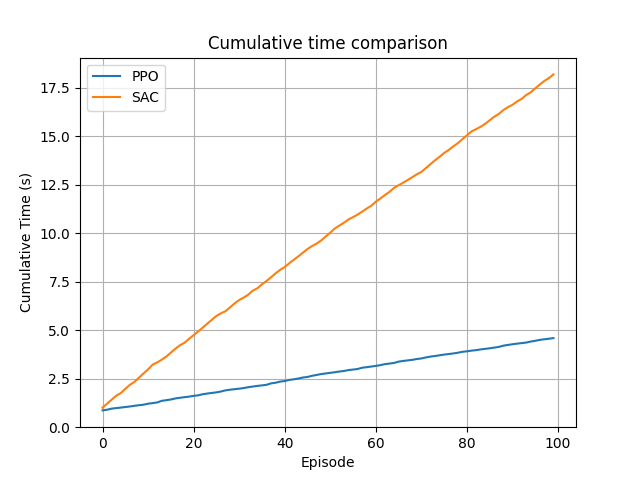
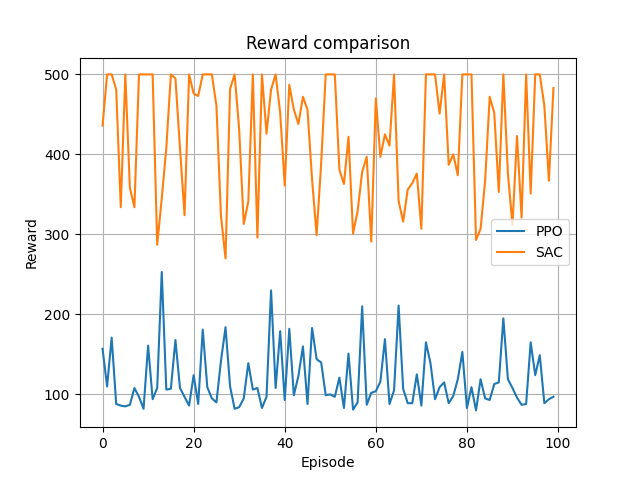
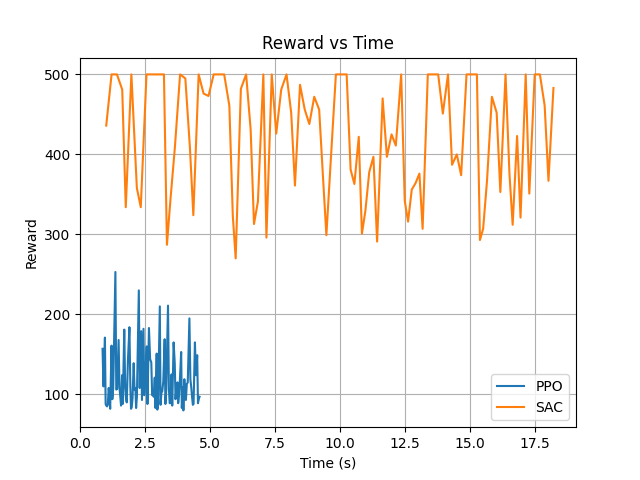
- **Comparison with RIENFORCE**
    PPO is better than reinforce. Reinforce uses a fixed sigma, which is not updated during training. This means that the agent is forced to explore forever. In contrast, PPO reduce its variance to zero, by becoming more secure about its strategy.
    Moreover, the reinforce with baseline seems to be better than the reinforce with normalization. Maybe, this happens because the average of batch is noisy. In a unlucky batch, the batch average is low and this do not increase strategy performance.

# References

**[1]** “Reinforcement Learning: An introduction (Second Edition)” by Richard S. Sutton and Andrew G. Barto, [PDF](http://incompleteideas.net/book/RLbook2020.pdf)

**[2]** Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017). Proximal policy optimization algorithms.

**[3]** Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018, July). Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor.